# Experiment No. 07
## Decision Trees, Pruning, and Overfitting

**Aim:** To implement a Decision Tree Classifier on the Titanic dataset, study how tree depth affects training and testing performance, identify overfitting, and apply cost-complexity pruning to balance predictive accuracy with model simplicity.

### Objectives

- Explain recursive partitioning, Gini impurity, and entropy.
- Train and compare unrestricted and shallow (`max_depth=3`) decision trees.
- Vary `max_depth` from 1 to 14 and inspect the train-test accuracy gap.
- Compare Gini and entropy splitting criteria.
- Generate a cost-complexity pruning path and evaluate candidate `ccp_alpha` values.
- Select pruning strength using training-set cross-validation, leaving the test set untouched until evaluation.
- Compare accuracy, generalisation, and structural complexity.
- Visualise and interpret the final trees.

> The Titanic data is used only as a historical classroom dataset. The fitted patterns describe this file and should not be interpreted as causal claims about survival.


## 1. Decision-tree concepts

A decision tree recursively selects feature thresholds or categories that produce purer child nodes.

For class proportions $p_k$ in a node:

- **Gini impurity:** $G = 1 - \sum_k p_k^2$
- **Entropy:** $H = -\sum_k p_k \log_2(p_k)$, with zero-probability terms treated as zero.

A split is preferred when it produces the largest weighted decrease in impurity. An unrestricted tree can keep splitting until leaves are pure or cannot be split, which often gives low bias but high variance. Limiting `max_depth` is **pre-pruning**. Setting `ccp_alpha > 0` performs **post-pruning** by penalising additional leaf complexity.


## 2. Import libraries


In [1]:
from pathlib import Path
import warnings

import matplotlib.pyplot as plt
import numpy as np
import pandas as pd
import seaborn as sns
from sklearn.base import clone
from sklearn.compose import ColumnTransformer
from sklearn.impute import SimpleImputer
from sklearn.metrics import (
    ConfusionMatrixDisplay,
    accuracy_score,
    balanced_accuracy_score,
    confusion_matrix,
    f1_score,
    precision_score,
    recall_score,
)
from sklearn.model_selection import GridSearchCV, StratifiedKFold, train_test_split
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.tree import DecisionTreeClassifier, plot_tree

RANDOM_STATE = 42
TEST_SIZE = 0.20
sns.set_theme(style="whitegrid", context="notebook")
pd.set_option("display.max_columns", 30)
pd.set_option("display.float_format", lambda value: f"{value:.4f}")


## 3. Load and audit the Titanic dataset

The path logic works when the notebook is run from either the repository root or the `Week 7` directory. The source CSV is read but never modified.


In [2]:
file_name = "Titanic-Dataset.csv"
candidate_paths = [Path(file_name), Path("Week 7") / file_name]
data_path = next((path for path in candidate_paths if path.exists()), None)
if data_path is None:
    raise FileNotFoundError(
        f"Could not find {file_name!r} in the notebook directory or Week 7/."
    )

raw_data = pd.read_csv(data_path)
data = raw_data.copy()

print(f"Loaded: {data_path.resolve()}")
print(f"Shape: {data.shape}")
print(f"Exact duplicate rows: {data.duplicated().sum()}")
data.head()


Loaded: D:\Programming\SEM-5 ML labs\Week 7\Titanic-Dataset.csv
Shape: (891, 12)
Exact duplicate rows: 0


,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0000,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0000,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0000,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0000,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0000,0,0,373450,8.0500,NaN,S


In [3]:
quality_summary = pd.DataFrame({
    "dtype": data.dtypes.astype(str),
    "missing": data.isna().sum(),
    "missing_percent": 100 * data.isna().mean(),
    "unique": data.nunique(dropna=False),
})
display(quality_summary)

target_summary = (
    data["Survived"].value_counts().sort_index()
    .rename(index={0: "Did not survive", 1: "Survived"})
    .rename_axis("class")
    .to_frame("rows")
)
target_summary["percent"] = 100 * target_summary["rows"] / len(data)
display(target_summary)


,dtype,missing,missing_percent,unique
PassengerId,int64,0,0.0000,891
Survived,int64,0,0.0000,2
Pclass,int64,0,0.0000,3
Name,object,0,0.0000,891
Sex,object,0,0.0000,2
Age,float64,177,19.8653,89
SibSp,int64,0,0.0000,7
Parch,int64,0,0.0000,7
Ticket,object,0,0.0000,681
Fare,float64,0,0.0000,248


,rows,percent
class,,
Did not survive,549,61.6162
Survived,342,38.3838


### Feature decisions

The target is `Survived` (0 = did not survive, 1 = survived).

Used predictors:

- Numeric: `Age`, `SibSp`, `Parch`, and `Fare`
- Categorical: `Pclass`, `Sex`, and `Embarked`

`PassengerId` is a row identifier. `Name` and `Ticket` are high-cardinality identifiers/text fields. `Cabin` is excluded because most values are missing and raw cabin strings are sparse. Excluding these columns keeps this introductory model interpretable and avoids learning passenger-specific labels. Numeric values are median-imputed, while categorical values are most-frequent-imputed and one-hot encoded. Scaling is unnecessary because tree splits depend on ordering, not distance.


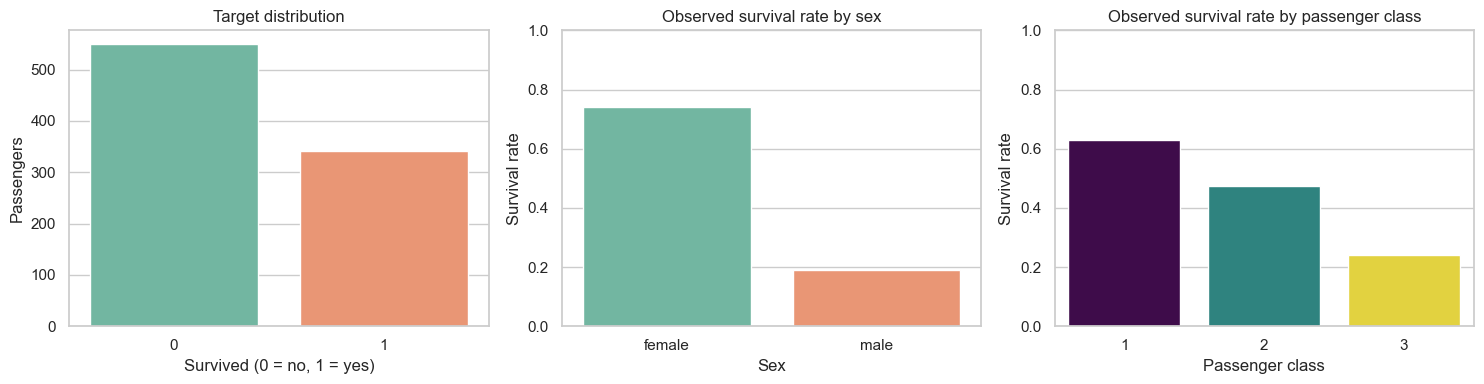

In [4]:
numeric_features = ["Age", "SibSp", "Parch", "Fare"]
categorical_features = ["Pclass", "Sex", "Embarked"]
feature_columns = numeric_features + categorical_features
excluded_columns = ["PassengerId", "Name", "Ticket", "Cabin"]

fig, axes = plt.subplots(1, 3, figsize=(15, 4))

sns.countplot(
    data=data, x="Survived", hue="Survived", palette="Set2",
    legend=False, ax=axes[0]
)
axes[0].set(
    title="Target distribution",
    xlabel="Survived (0 = no, 1 = yes)",
    ylabel="Passengers",
)

survival_by_sex = data.groupby("Sex", observed=True)["Survived"].mean().reset_index()
sns.barplot(
    data=survival_by_sex, x="Sex", y="Survived", hue="Sex",
    palette="Set2", legend=False, ax=axes[1]
)
axes[1].set(
    title="Observed survival rate by sex",
    xlabel="Sex", ylabel="Survival rate", ylim=(0, 1),
)

survival_by_class = data.groupby("Pclass", observed=True)["Survived"].mean().reset_index()
sns.barplot(
    data=survival_by_class, x="Pclass", y="Survived", hue="Pclass",
    palette="viridis", legend=False, ax=axes[2]
)
axes[2].set(
    title="Observed survival rate by passenger class",
    xlabel="Passenger class", ylabel="Survival rate", ylim=(0, 1),
)

plt.tight_layout()
plt.show()


## 4. Create a reproducible stratified split

Stratification preserves the class proportion. All imputers and encoders are fitted inside model pipelines, so the held-out test data does not influence preprocessing.


In [5]:
X = data[feature_columns].copy()
y = data["Survived"].astype(int).copy()

X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=TEST_SIZE,
    random_state=RANDOM_STATE,
    stratify=y,
)

split_summary = pd.DataFrame({
    "rows": [len(X_train), len(X_test)],
    "survivors": [int(y_train.sum()), int(y_test.sum())],
    "survival_rate": [y_train.mean(), y_test.mean()],
}, index=["Training", "Testing"])
split_summary


,rows,survivors,survival_rate
Training,712,273,0.3834
Testing,179,69,0.3855


## 5. Build preprocessing and tree pipelines


In [6]:
numeric_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="median")),
])
categorical_pipeline = Pipeline([
    ("imputer", SimpleImputer(strategy="most_frequent")),
    ("encoder", OneHotEncoder(handle_unknown="ignore")),
])
preprocessor = ColumnTransformer([
    ("numeric", numeric_pipeline, numeric_features),
    ("categorical", categorical_pipeline, categorical_features),
])

def make_tree_pipeline(*, criterion="gini", max_depth=None, ccp_alpha=0.0):
    return Pipeline([
        ("preprocessor", clone(preprocessor)),
        ("classifier", DecisionTreeClassifier(
            criterion=criterion,
            max_depth=max_depth,
            ccp_alpha=ccp_alpha,
            random_state=RANDOM_STATE,
        )),
    ])

unrestricted_tree = make_tree_pipeline()
shallow_tree = make_tree_pipeline(max_depth=3)

unrestricted_tree.fit(X_train, y_train)
shallow_tree.fit(X_train, y_train)
print("Unrestricted and shallow trees fitted successfully.")


Unrestricted and shallow trees fitted successfully.


## 6. Compare the unrestricted and shallow trees

Accuracy is reported for the training and untouched test sets. Precision, recall, specificity, F1-score, and balanced accuracy provide a more complete view of held-out performance.


In [7]:
def classification_metrics(model, features, labels):
    predictions = model.predict(features)
    tn, fp, fn, tp = confusion_matrix(labels, predictions, labels=[0, 1]).ravel()
    return {
        "Accuracy": accuracy_score(labels, predictions),
        "Balanced accuracy": balanced_accuracy_score(labels, predictions),
        "Precision": precision_score(labels, predictions, zero_division=0),
        "Recall": recall_score(labels, predictions, zero_division=0),
        "Specificity": tn / (tn + fp),
        "F1-score": f1_score(labels, predictions, zero_division=0),
    }

def model_summary(name, model):
    classifier = model.named_steps["classifier"]
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_metrics = classification_metrics(model, X_test, y_test)
    return {
        "Model": name,
        "Train accuracy": train_accuracy,
        "Test accuracy": test_metrics["Accuracy"],
        "Train-test gap": train_accuracy - test_metrics["Accuracy"],
        "Balanced accuracy": test_metrics["Balanced accuracy"],
        "Precision": test_metrics["Precision"],
        "Recall": test_metrics["Recall"],
        "Specificity": test_metrics["Specificity"],
        "F1-score": test_metrics["F1-score"],
        "Depth": classifier.get_depth(),
        "Nodes": classifier.tree_.node_count,
        "Leaves": classifier.get_n_leaves(),
    }

deep_shallow_results = pd.DataFrame([
    model_summary("Unrestricted tree", unrestricted_tree),
    model_summary("Shallow tree (max_depth=3)", shallow_tree),
]).set_index("Model")
deep_shallow_results


,Train accuracy,Test accuracy,Train-test gap,Balanced accuracy,Precision,Recall,Specificity,F1-score,Depth,Nodes,Leaves
Model,,,,,,,,,,,
Unrestricted tree,0.9831,0.8156,0.1675,0.7987,0.7812,0.7246,0.8727,0.7519,23,303,152
Shallow tree (max_depth=3),0.8329,0.7933,0.0396,0.7481,0.8636,0.5507,0.9455,0.6726,3,15,8


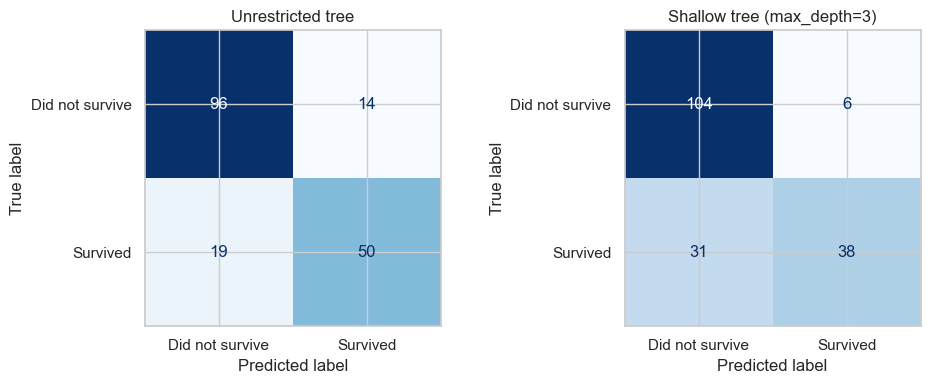

In [8]:
fig, axes = plt.subplots(1, 2, figsize=(10, 4))
for ax, (name, model) in zip(
    axes,
    {
        "Unrestricted tree": unrestricted_tree,
        "Shallow tree (max_depth=3)": shallow_tree,
    }.items(),
):
    ConfusionMatrixDisplay.from_predictions(
        y_test,
        model.predict(X_test),
        labels=[0, 1],
        display_labels=["Did not survive", "Survived"],
        cmap="Blues",
        colorbar=False,
        ax=ax,
    )
    ax.set_title(name)
plt.tight_layout()
plt.show()


The unrestricted tree is expected to fit the training data very closely. A substantially larger train-test gap than the shallow tree is evidence of high variance (overfitting), not proof that every deep tree will fail.


## 7. Visualise the shallow tree


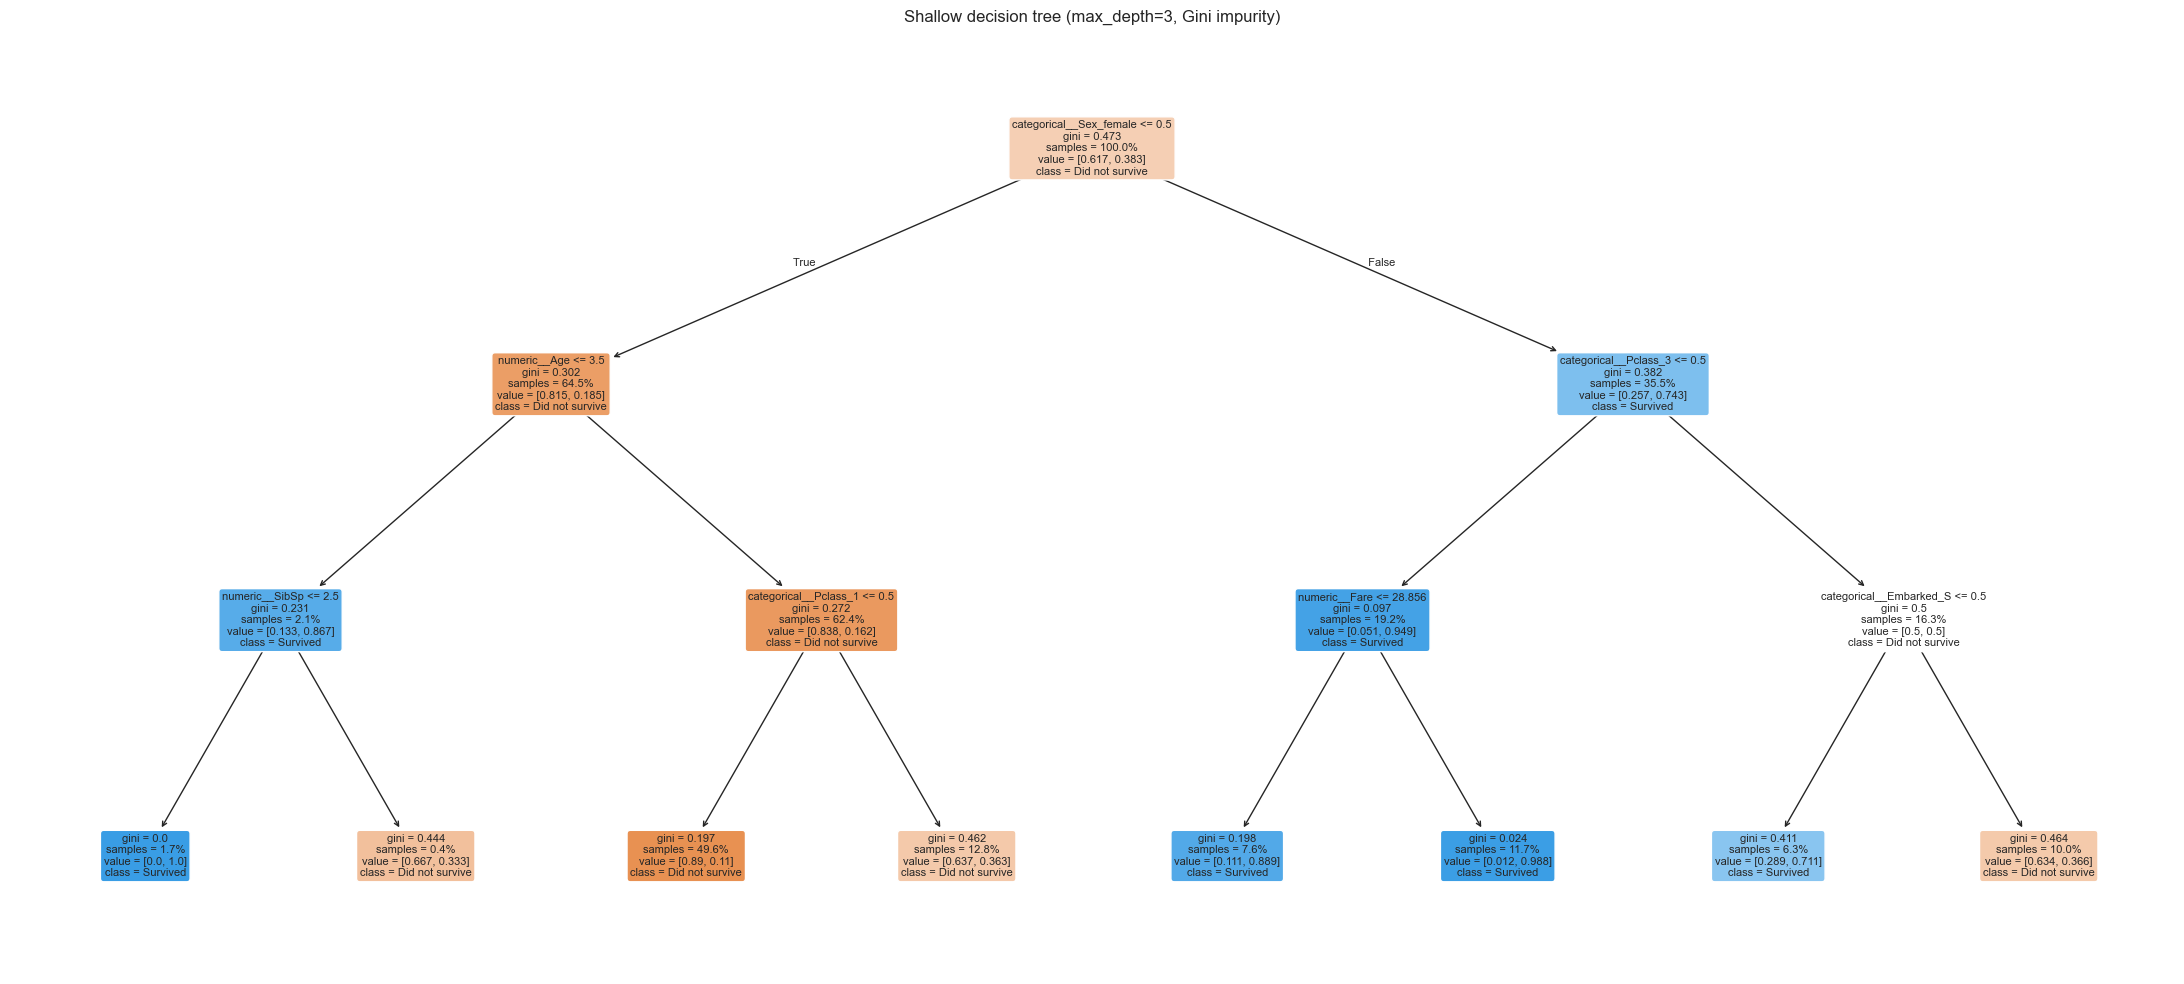

In [9]:
shallow_feature_names = (
    shallow_tree.named_steps["preprocessor"].get_feature_names_out()
)
plt.figure(figsize=(22, 10))
plot_tree(
    shallow_tree.named_steps["classifier"],
    feature_names=shallow_feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    fontsize=8,
)
plt.title("Shallow decision tree (max_depth=3, Gini impurity)")
plt.tight_layout()
plt.show()


## 8. Compare Gini impurity and entropy

Both criteria measure node impurity but use different formulas. To make the comparison fair, both models use the same split, preprocessing, random seed, and `max_depth=3`.


In [10]:
criterion_models = {
    "Gini": make_tree_pipeline(criterion="gini", max_depth=3),
    "Entropy": make_tree_pipeline(criterion="entropy", max_depth=3),
}
for model in criterion_models.values():
    model.fit(X_train, y_train)

criterion_results = pd.DataFrame([
    model_summary(name, model)
    for name, model in criterion_models.items()
]).set_index("Model")
criterion_results


,Train accuracy,Test accuracy,Train-test gap,Balanced accuracy,Precision,Recall,Specificity,F1-score,Depth,Nodes,Leaves
Model,,,,,,,,,,,
Gini,0.8329,0.7933,0.0396,0.7481,0.8636,0.5507,0.9455,0.6726,3,15,8
Entropy,0.8258,0.8045,0.0214,0.7761,0.8036,0.6522,0.9000,0.7200,3,15,8


## 9. Study maximum depth from 1 to 14

A depth is not selected from the test curve; the plot is used to diagnose model behaviour. Pruning strength will be selected separately using cross-validation on the training set.


In [11]:
depth_rows = []
depth_models = {}
for depth in range(1, 15):
    model = make_tree_pipeline(max_depth=depth)
    model.fit(X_train, y_train)
    depth_models[depth] = model
    classifier = model.named_steps["classifier"]
    train_accuracy = accuracy_score(y_train, model.predict(X_train))
    test_accuracy = accuracy_score(y_test, model.predict(X_test))
    depth_rows.append({
        "Max depth": depth,
        "Train accuracy": train_accuracy,
        "Test accuracy": test_accuracy,
        "Train-test gap": train_accuracy - test_accuracy,
        "Actual depth": classifier.get_depth(),
        "Nodes": classifier.tree_.node_count,
        "Leaves": classifier.get_n_leaves(),
    })

depth_results = pd.DataFrame(depth_rows).set_index("Max depth")
display(depth_results)

best_observed_depth = int(depth_results["Test accuracy"].idxmax())
print(
    f"Highest observed test accuracy in this diagnostic sweep: "
    f"depth {best_observed_depth} "
    f"({depth_results.loc[best_observed_depth, 'Test accuracy']:.4f})."
)


,Train accuracy,Test accuracy,Train-test gap,Actual depth,Nodes,Leaves
Max depth,,,,,,
1,0.7893,0.7765,0.0128,1,3,2
2,0.8048,0.7598,0.0450,2,7,4
3,0.8329,0.7933,0.0396,3,15,8
4,0.8413,0.7877,0.0536,4,29,15
5,0.8652,0.7598,0.1054,5,45,23
6,0.8862,0.7989,0.0874,6,69,35
7,0.8933,0.7989,0.0944,7,97,49
8,0.9157,0.7989,0.1168,8,123,62
9,0.9298,0.8212,0.1085,9,151,76


Highest observed test accuracy in this diagnostic sweep: depth 9 (0.8212).


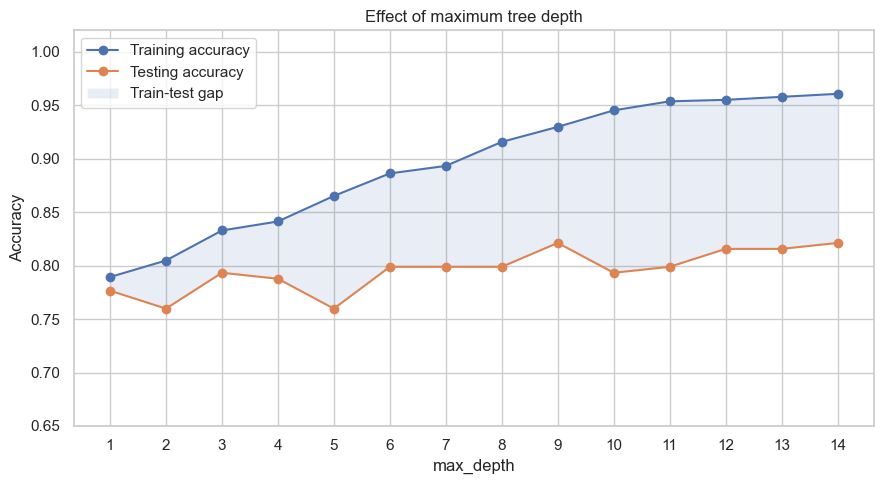

In [12]:
fig, ax = plt.subplots(figsize=(9, 5))
ax.plot(
    depth_results.index, depth_results["Train accuracy"],
    marker="o", label="Training accuracy"
)
ax.plot(
    depth_results.index, depth_results["Test accuracy"],
    marker="o", label="Testing accuracy"
)
ax.fill_between(
    depth_results.index,
    depth_results["Test accuracy"],
    depth_results["Train accuracy"],
    alpha=0.12,
    label="Train-test gap",
)
ax.set(
    title="Effect of maximum tree depth",
    xlabel="max_depth",
    ylabel="Accuracy",
    xticks=range(1, 15),
    ylim=(0.65, 1.02),
)
ax.legend()
plt.tight_layout()
plt.show()


## 10. Cost-complexity pruning path

For a subtree $T$, cost-complexity pruning minimises

$$R_\alpha(T) = R(T) + \alpha |T_{leaves}|,$$

where $R(T)$ is total leaf impurity and $\alpha$ (implemented as `ccp_alpha`) penalises the number of leaves. Larger values produce smaller trees.

The candidate path is generated from training data only. Candidate alphas are evaluated by five-fold stratified cross-validation on the training set. The **one-standard-error rule** selects the largest alpha whose mean validation accuracy is within one standard error of the best mean. This intentionally favours the simpler model among statistically similar candidates. The held-out test labels are not used in this selection.


In [13]:
path_preprocessor = clone(preprocessor)
X_train_transformed = path_preprocessor.fit_transform(X_train)
path_tree = DecisionTreeClassifier(random_state=RANDOM_STATE)
pruning_path = path_tree.cost_complexity_pruning_path(
    X_train_transformed, y_train
)

# The final alpha collapses the tree to a single root, so omit it.
candidate_alphas = np.unique(pruning_path.ccp_alphas[:-1])
if len(candidate_alphas) > 60:
    candidate_alphas = np.unique(
        np.quantile(candidate_alphas, np.linspace(0, 1, 60))
    )

print(f"Candidate ccp_alpha values evaluated: {len(candidate_alphas)}")
print(f"Range: {candidate_alphas.min():.6f} to {candidate_alphas.max():.6f}")


Candidate ccp_alpha values evaluated: 60
Range: 0.000000 to 0.035556


In [14]:
cv = StratifiedKFold(n_splits=5, shuffle=True, random_state=RANDOM_STATE)
pruning_search = GridSearchCV(
    estimator=make_tree_pipeline(),
    param_grid={"classifier__ccp_alpha": candidate_alphas},
    scoring="accuracy",
    cv=cv,
    n_jobs=-1,
    refit=False,
    return_train_score=True,
)
with warnings.catch_warnings():
    warnings.filterwarnings(
        "ignore", message="Found unknown categories.*", category=UserWarning
    )
    pruning_search.fit(X_train, y_train)

pruning_cv = pd.DataFrame({
    "ccp_alpha": pruning_search.cv_results_["param_classifier__ccp_alpha"].astype(float),
    "mean_train_accuracy": pruning_search.cv_results_["mean_train_score"],
    "mean_validation_accuracy": pruning_search.cv_results_["mean_test_score"],
    "std_validation_accuracy": pruning_search.cv_results_["std_test_score"],
}).sort_values("ccp_alpha").reset_index(drop=True)
pruning_cv["validation_standard_error"] = (
    pruning_cv["std_validation_accuracy"] / np.sqrt(cv.get_n_splits())
)

best_mean_position = int(pruning_cv["mean_validation_accuracy"].to_numpy().argmax())
best_mean = pruning_cv.loc[best_mean_position, "mean_validation_accuracy"]
best_standard_error = pruning_cv.loc[
    best_mean_position, "validation_standard_error"
]
one_se_cutoff = best_mean - best_standard_error
eligible = pruning_cv[
    pruning_cv["mean_validation_accuracy"] >= one_se_cutoff
]
selected_alpha = float(eligible["ccp_alpha"].max())

print(f"Best mean CV accuracy: {best_mean:.4f}")
print(f"One-standard-error cutoff: {one_se_cutoff:.4f}")
print(f"Selected ccp_alpha: {selected_alpha:.6f}")
display(
    pruning_cv.sort_values(
        ["mean_validation_accuracy", "ccp_alpha"],
        ascending=[False, False],
    ).head(10)
)


Best mean CV accuracy: 0.8090
One-standard-error cutoff: 0.8028
Selected ccp_alpha: 0.009053


,ccp_alpha,mean_train_accuracy,mean_validation_accuracy,std_validation_accuracy,validation_standard_error
53,0.0046,0.8592,0.8090,0.0138,0.0062
52,0.0044,0.8624,0.8090,0.0138,0.0062
51,0.0043,0.8624,0.8090,0.0138,0.0062
48,0.0032,0.8771,0.8062,0.0179,0.0080
56,0.0091,0.8339,0.8048,0.0112,0.0050
54,0.0057,0.8438,0.8034,0.0135,0.0060
55,0.0062,0.8409,0.8034,0.0113,0.0050
50,0.0038,0.8704,0.8034,0.0169,0.0076
49,0.0034,0.8743,0.8034,0.0169,0.0076
40,0.0022,0.9228,0.8020,0.0112,0.0050


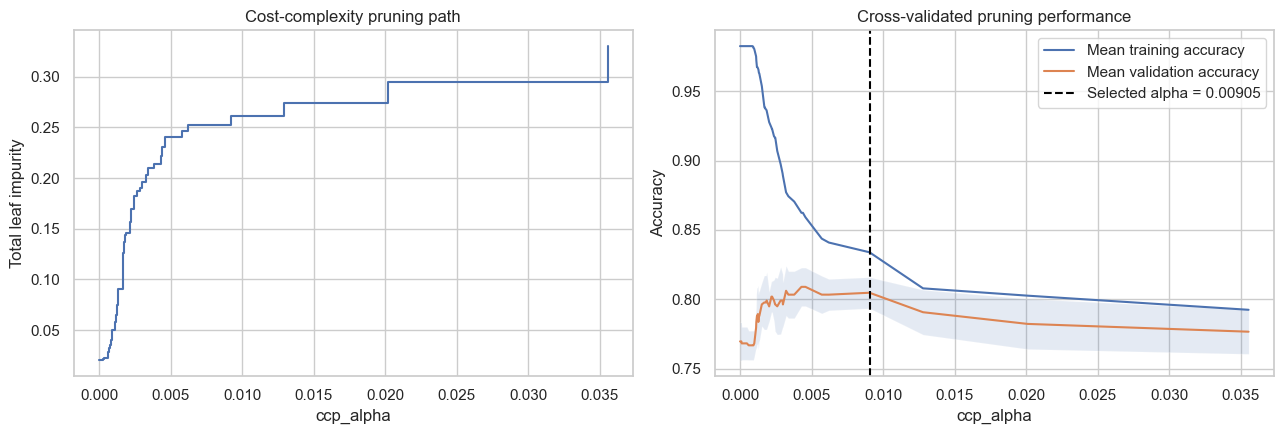

In [15]:
fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].step(
    pruning_path.ccp_alphas[:-1],
    pruning_path.impurities[:-1],
    where="post",
)
axes[0].set(
    title="Cost-complexity pruning path",
    xlabel="ccp_alpha",
    ylabel="Total leaf impurity",
)

axes[1].plot(
    pruning_cv["ccp_alpha"],
    pruning_cv["mean_train_accuracy"],
    label="Mean training accuracy",
)
axes[1].plot(
    pruning_cv["ccp_alpha"],
    pruning_cv["mean_validation_accuracy"],
    label="Mean validation accuracy",
)
axes[1].fill_between(
    pruning_cv["ccp_alpha"],
    pruning_cv["mean_validation_accuracy"]
        - pruning_cv["std_validation_accuracy"],
    pruning_cv["mean_validation_accuracy"]
        + pruning_cv["std_validation_accuracy"],
    alpha=0.15,
)
axes[1].axvline(
    selected_alpha,
    color="black",
    linestyle="--",
    label=f"Selected alpha = {selected_alpha:.5f}",
)
axes[1].set(
    title="Cross-validated pruning performance",
    xlabel="ccp_alpha",
    ylabel="Accuracy",
)
axes[1].legend()

plt.tight_layout()
plt.show()


## 11. Fit and compare the pruned tree

The selected alpha is now used to fit one model on the complete training set. Only after selection is its test performance measured.


In [16]:
pruned_tree = make_tree_pipeline(ccp_alpha=selected_alpha)
pruned_tree.fit(X_train, y_train)

final_models = {
    "Unrestricted tree": unrestricted_tree,
    "Shallow tree (max_depth=3)": shallow_tree,
    "Pruned tree (CV-selected alpha)": pruned_tree,
}
final_comparison = pd.DataFrame([
    model_summary(name, model)
    for name, model in final_models.items()
]).set_index("Model")
final_comparison


,Train accuracy,Test accuracy,Train-test gap,Balanced accuracy,Precision,Recall,Specificity,F1-score,Depth,Nodes,Leaves
Model,,,,,,,,,,,
Unrestricted tree,0.9831,0.8156,0.1675,0.7987,0.7812,0.7246,0.8727,0.7519,23,303,152
Shallow tree (max_depth=3),0.8329,0.7933,0.0396,0.7481,0.8636,0.5507,0.9455,0.6726,3,15,8
Pruned tree (CV-selected alpha),0.8315,0.7765,0.0549,0.7345,0.8085,0.5507,0.9182,0.6552,3,11,6


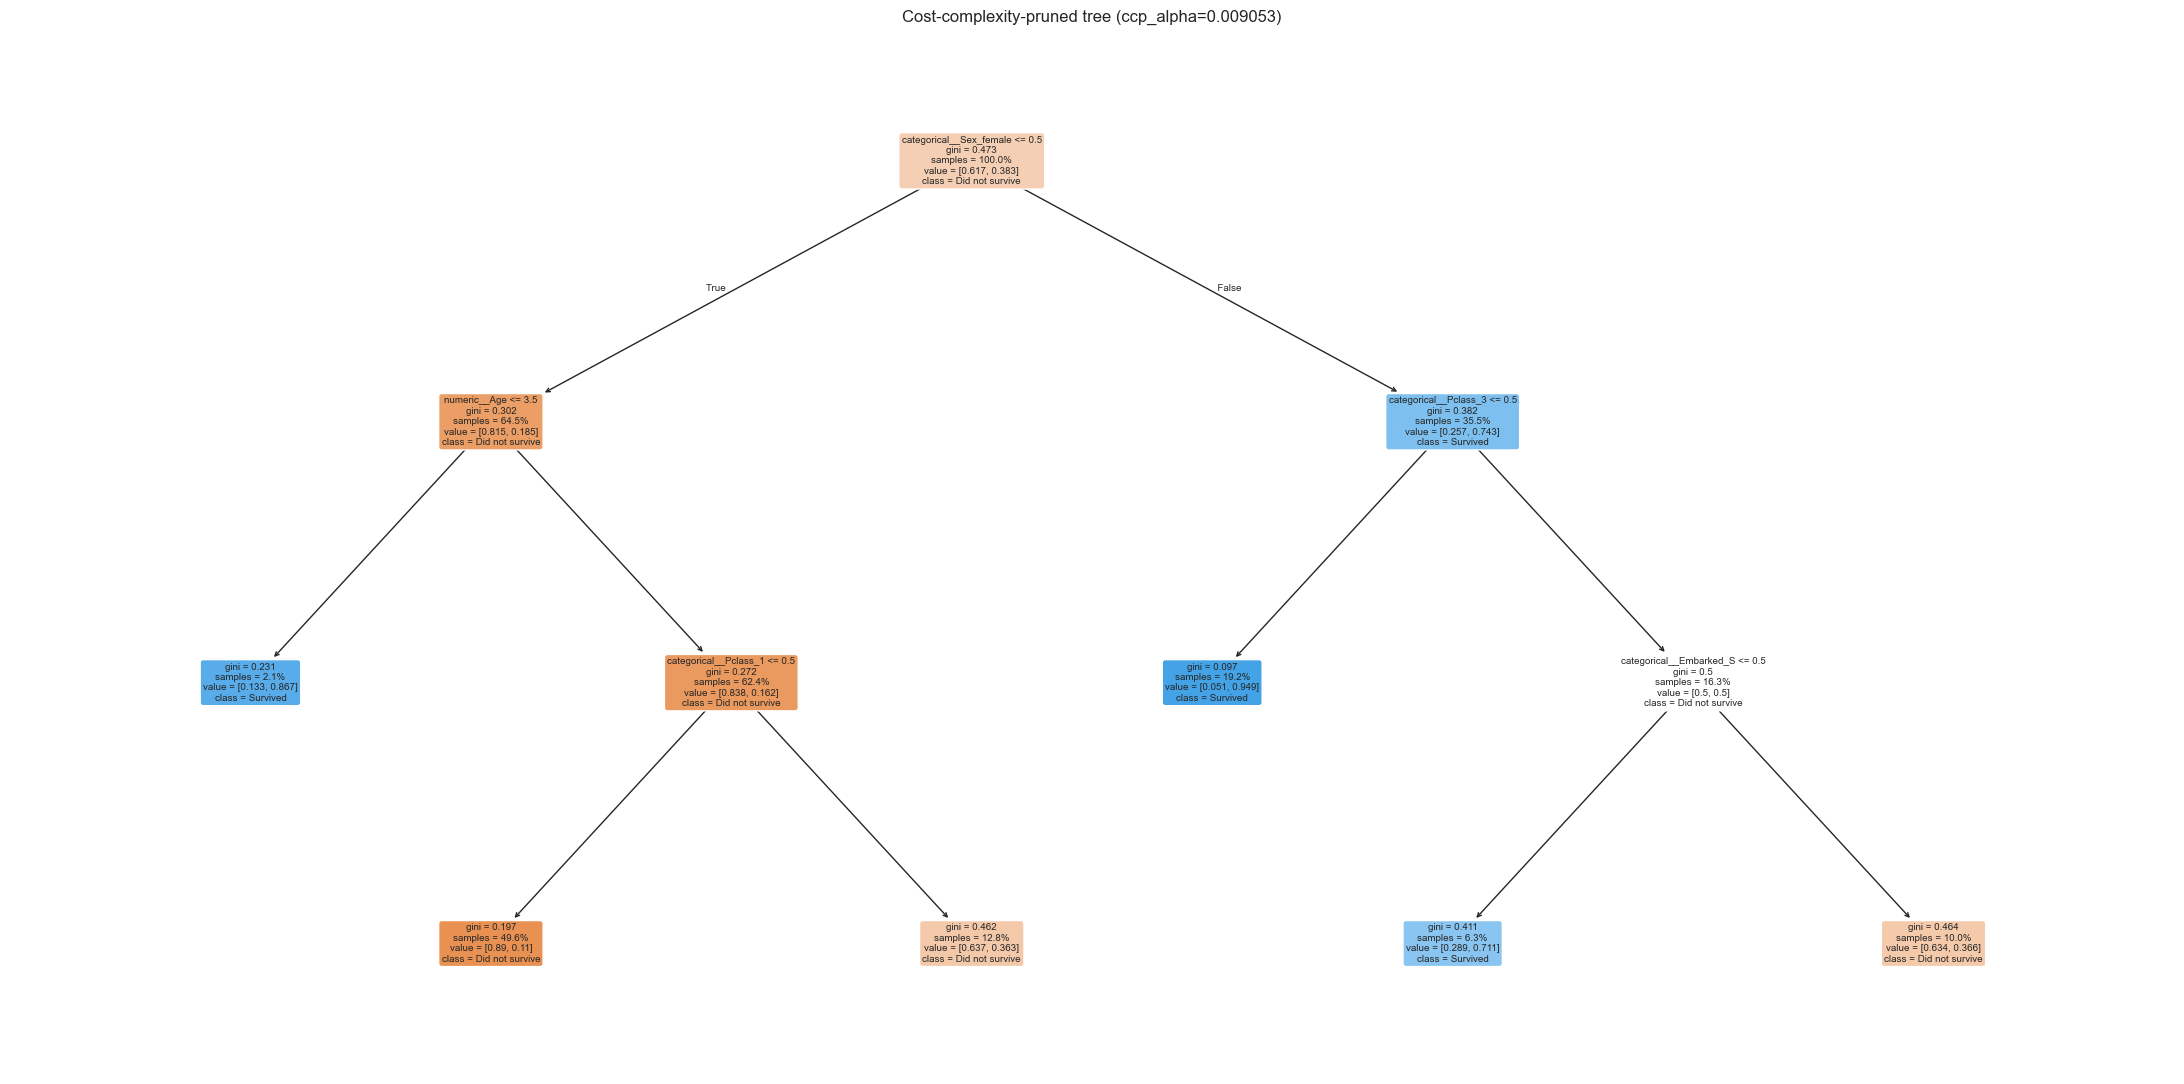

In [17]:
pruned_feature_names = pruned_tree.named_steps[
    "preprocessor"
].get_feature_names_out()
plt.figure(figsize=(22, 11))
plot_tree(
    pruned_tree.named_steps["classifier"],
    feature_names=pruned_feature_names,
    class_names=["Did not survive", "Survived"],
    filled=True,
    rounded=True,
    proportion=True,
    precision=3,
    fontsize=7,
)
plt.title(
    f"Cost-complexity-pruned tree (ccp_alpha={selected_alpha:.6f})"
)
plt.tight_layout()
plt.show()


## 12. Feature importance of the pruned tree

Impurity-based importance is the normalised total reduction in the splitting criterion attributed to each transformed feature. It describes how this fitted tree split the data; it is not a causal effect and can favour features with more possible split points.


,Feature,Importance
0,categorical__Sex_female,0.6467
1,categorical__Pclass_3,0.1612
2,numeric__Age,0.0917
3,categorical__Pclass_1,0.0586
4,categorical__Embarked_S,0.0417
5,numeric__Fare,0.0000
6,numeric__SibSp,0.0000
7,numeric__Parch,0.0000
8,categorical__Pclass_2,0.0000
9,categorical__Sex_male,0.0000


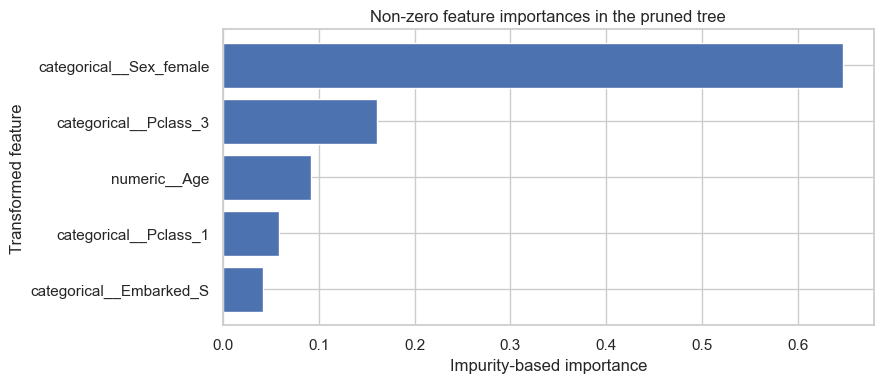

In [18]:
feature_importance = (
    pd.DataFrame({
        "Feature": pruned_feature_names,
        "Importance": pruned_tree.named_steps[
            "classifier"
        ].feature_importances_,
    })
    .sort_values("Importance", ascending=False)
    .reset_index(drop=True)
)
display(feature_importance)

nonzero_importance = feature_importance[
    feature_importance["Importance"] > 0
].sort_values("Importance")
plt.figure(figsize=(9, max(4, 0.45 * len(nonzero_importance))))
plt.barh(
    nonzero_importance["Feature"],
    nonzero_importance["Importance"],
    color="#4c72b0",
)
plt.title("Non-zero feature importances in the pruned tree")
plt.xlabel("Impurity-based importance")
plt.ylabel("Transformed feature")
plt.tight_layout()
plt.show()


## 13. Automated checks


In [19]:
assert data.shape == (891, 12), "Unexpected Titanic dataset shape"
assert set(data["Survived"].unique()) == {0, 1}
assert set(feature_columns).isdisjoint(excluded_columns)
assert X_train.index.intersection(X_test.index).empty, "Train/test overlap detected"
assert len(X_train) + len(X_test) == len(data)
assert abs(y_train.mean() - y_test.mean()) < 0.01, "Stratification check failed"
assert list(depth_results.index) == list(range(1, 15))
assert depth_results["Train accuracy"].between(0, 1).all()
assert depth_results["Test accuracy"].between(0, 1).all()
assert selected_alpha >= 0
assert pruned_tree.named_steps["classifier"].tree_.node_count <= (
    unrestricted_tree.named_steps["classifier"].tree_.node_count
)
assert np.isclose(feature_importance["Importance"].sum(), 1.0)
print("All data, split, depth-sweep, pruning, and importance checks passed.")


All data, split, depth-sweep, pruning, and importance checks passed.


## 14. Conclusion and observations


In [20]:
deep = final_comparison.loc["Unrestricted tree"]
shallow = final_comparison.loc["Shallow tree (max_depth=3)"]
pruned = final_comparison.loc["Pruned tree (CV-selected alpha)"]

print(
    f"The unrestricted tree reached {deep['Train accuracy']:.2%} training "
    f"accuracy but {deep['Test accuracy']:.2%} test accuracy, creating a "
    f"{deep['Train-test gap']:.2%} gap. It used {int(deep['Nodes'])} nodes "
    f"and {int(deep['Leaves'])} leaves."
)
print(
    f"The depth-3 tree achieved {shallow['Test accuracy']:.2%} test "
    f"accuracy with {int(shallow['Nodes'])} nodes."
)
print(
    f"Cross-validation selected ccp_alpha={selected_alpha:.6f}. The pruned "
    f"tree achieved {pruned['Test accuracy']:.2%} test accuracy with "
    f"{int(pruned['Nodes'])} nodes and {int(pruned['Leaves'])} leaves."
)
print(
    "The deep tree's near-perfect training fit and larger held-out gap are "
    "consistent with overfitting. Depth restriction and cost-complexity "
    "pruning reduce variance and make the model easier to inspect. Results "
    "depend on this split and dataset; they are not causal survival rules."
)


The unrestricted tree reached 98.31% training accuracy but 81.56% test accuracy, creating a 16.75% gap. It used 303 nodes and 152 leaves.
The depth-3 tree achieved 79.33% test accuracy with 15 nodes.
Cross-validation selected ccp_alpha=0.009053. The pruned tree achieved 77.65% test accuracy with 11 nodes and 6 leaves.
The deep tree's near-perfect training fit and larger held-out gap are consistent with overfitting. Depth restriction and cost-complexity pruning reduce variance and make the model easier to inspect. Results depend on this split and dataset; they are not causal survival rules.


## Viva Questions - Short Answers

1. **What is a decision tree?** A supervised model that predicts by following a sequence of feature-based decisions from a root node to a leaf.
2. **What is the difference between a classification tree and a regression tree?** A classification tree predicts a class or class probability; a regression tree predicts a numeric value, usually a leaf mean.
3. **What is Gini impurity?** $1-\sum_k p_k^2$; it is the probability of mislabelling a randomly selected sample if labels were assigned according to the node's class proportions.
4. **What is entropy in a decision tree?** $-\sum_k p_k\log_2(p_k)$; it measures class uncertainty and is zero for a pure node.
5. **Why does an unrestricted decision tree tend to overfit?** It can create highly specific branches that capture noise and individual training examples, producing high variance.
6. **What does `max_depth` control?** It limits the longest root-to-leaf path and therefore constrains structural complexity.
7. **What happens if `max_depth` is too small?** The tree may underfit: both training and testing performance can be poor because important patterns cannot be represented.
8. **What happens if `max_depth` is too large?** Training accuracy usually increases, but variance and the train-test gap can increase as the tree models noise.
9. **What is pruning?** Pruning removes or prevents weak branches to reduce complexity and improve generalisation and interpretability.
10. **What is `ccp_alpha`?** It is scikit-learn's non-negative cost-complexity penalty. Larger values penalise additional leaves more strongly and produce smaller trees.
